In [1]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [2]:
# Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
# G = Graphs[9]
G = nx.karate_club_graph()

In [4]:
results_dir = "karate"
# os.mkdir(results_dir)

In [14]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [15]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
it_searcher = IterativeSearcher(adv_sampler)

In [16]:
results = it_searcher.run_with_sampleset_info(num_runs=1, saving_path=f"{results_dir}/", return_metadata=True)

100%|██████████| 1/1 [00:15<00:00, 15.22s/it]


In [141]:
results

rec.array([(list([[0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21], [4, 5, 6, 10, 16], [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33], [23, 24, 25, 27, 28, 31]]), 0.44490358, 15.2027154, list([[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]], [[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]], [[0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21], [4, 5, 6, 10, 16], [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33], [23, 24, 25, 27, 28, 31]]]), list([0.0, 0.40362811791383213, 0.44490358126721763]), HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(9024., 20., 49.66, 24947.56, 837.44, 15923.56, 20.58, 19., 19.),
                      (7852., 20., 37.94, 23775.16, 880.84, 15923.16, 20.58, 22., 22.),
                      (7750., 20., 36.92, 23673.96, 731.04, 15923.96, 20.58,  1.,  1.),
                      (7082., 20., 30.24, 23005.56, 544.44,

In [12]:
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields


path = "karate/"

field_names = [f.name for f in fields(HierarchicalRunMetadata)]


sampleset_metadatas = []

print("Loading files...")

for run in range(1):
    hierarchical_run_metadata = HierarchicalRunMetadata.load_from_files(f"{path}_{run}")
    sampleset_metadatas.append(hierarchical_run_metadata)

Loading files...
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable


In [13]:
import numpy as np


communities = np.load(f"{path}_communities.npy", allow_pickle=True)
modularities = np.load(f"{path}_modularities.npy", allow_pickle=True)
division_modularities = np.load(f"{path}_division_modularities.npy", allow_pickle=True)
division_trees = np.load(f"{path}_division_trees.npy", allow_pickle=True)

In [142]:
communities = results.communities
modularities = results.modularity
division_trees = results.division_tree
division_modularities = results.division_modularities
times = results.time
sampleset_metadatas = results.samplesets_data

In [14]:
from Qommunity.searchers.utils import HierarchicalRunMetadata
from utils import recover_ordering, get_extended_nodes, plot_tree_extended


In [15]:
nodes, root = recover_ordering(G, division_tree=division_trees[0])
nodes, root = get_extended_nodes(root, nodes, sampleset_metadatas[0])
nodes

{-7731643862830242811: ExtendedNode(id=-7731643862830242811, community=[0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21], left=None, right=None, community_hash=-7731643862830242811, problem_id=3c152841-8e08-47dc-9b75-dd9c21a14537, chain_strength=3.215908954414038, chain_break_fraction=0.0, chain_break_method=majority_vote),
 4271490623099674619: ExtendedNode(id=4271490623099674619, community=[4, 5, 6, 10, 16], left=None, right=None, community_hash=4271490623099674619, problem_id=d5fd2f13-2035-425e-b400-17dd0238622b, chain_strength=3.3535053762503417, chain_break_fraction=0.0, chain_break_method=majority_vote),
 -4898839082539556396: ExtendedNode(id=-4898839082539556396, community=[8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33], left=None, right=None, community_hash=-4898839082539556396, problem_id=279482bd-dffe-4000-af53-93bfaa1a198f, chain_strength=2.854907620364309, chain_break_fraction=0.0, chain_break_method=majority_vote),
 7378259054148552592: ExtendedNode(id=7378259054148552592, community=

In [16]:
division_modularities[0]

[0.0, 0.40362811791383213, 0.44490358126721763]

c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


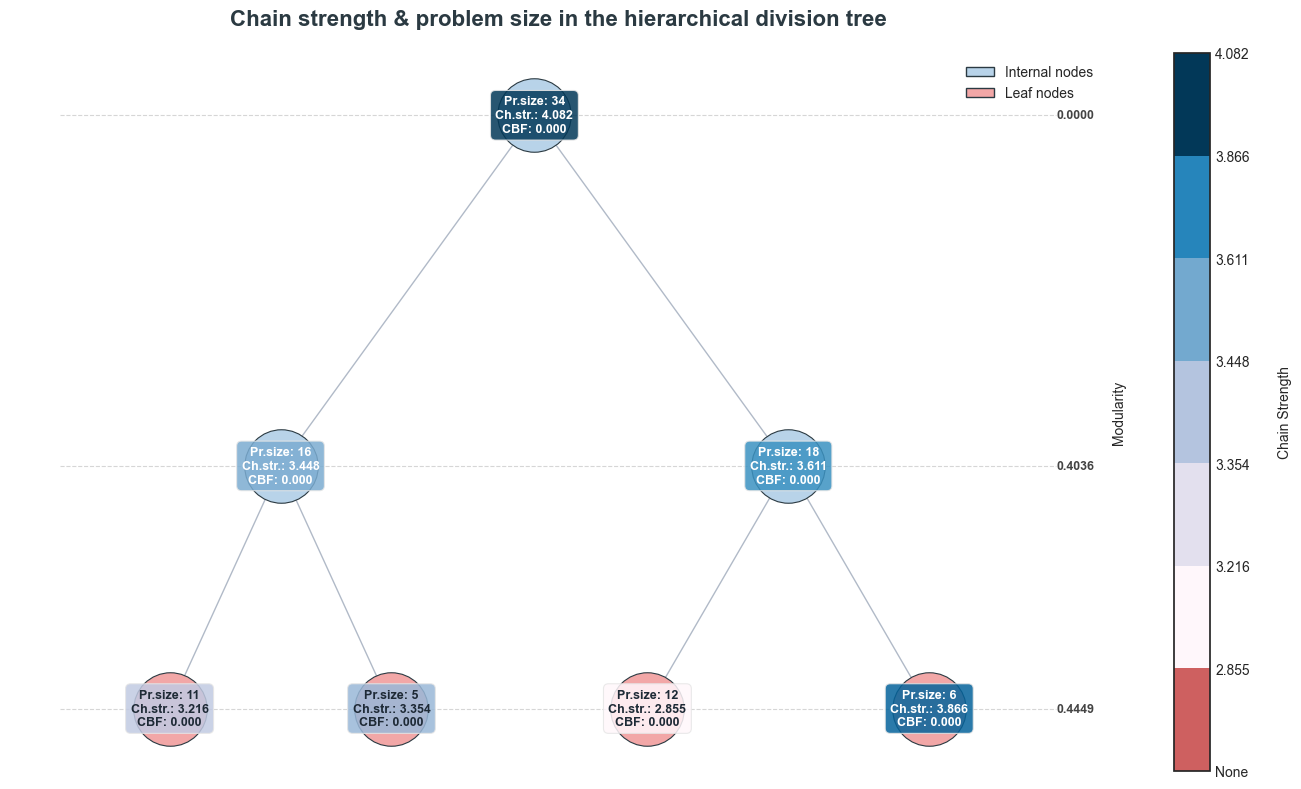

In [18]:
from matplotlib import colormaps
cmap = colormaps.get_cmap("PuBu")

plot_tree_extended(root, division_modularities[0], cmap=cmap)

In [18]:
mods = []
cbf_max = []
cbf_avg = []
max_cbf_div_mod = []
chain_strengths = []
comms_lens = []
energies = []
indices = []

for idx, sm in enumerate(sampleset_metadatas):
    # print(sm.chain_break_fraction)
    cbf_max.append(np.array(sm.chain_break_fraction).max())
    cbf_avg.append(np.array(sm.chain_break_fraction).mean())
    i = np.array(sm.chain_break_fraction).argmax()
    indices.append(i)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    max_cbf_div_mod.append(division_modularities[idx][i+1])
    comms_lens.append(communities[idx])

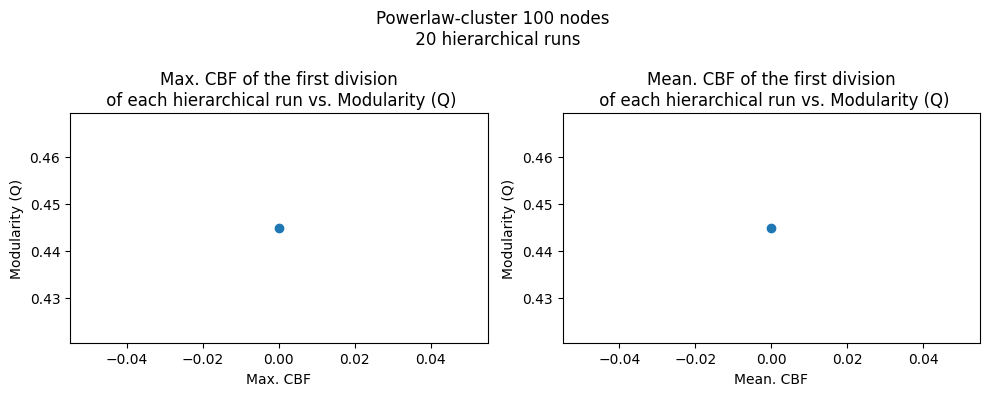

In [19]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Powerlaw-cluster 100 nodes \n 20 hierarchical runs")

ax[0].scatter(cbf_max, mods)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

In [20]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata

In [21]:
problem_ids = {}
energies = {}
qbits_involved = {}
mean_energies = {}
stds = {}
min_energies = {}
max_energies = {}
for run, sm in enumerate(sampleset_metadatas):
    problem_ids[run] = sm.problem_id
    en = []
    qbits = []
    me = []
    std = []
    for problem_id in sm.problem_id:
        pd = get_problem(problem_id=problem_id)
        en.append(pd.response.energies[0])
        qbits.append(len(pd.response.sampleset.variables))
        me.append(pd.response.sampleset.record.energy.mean())
        std.append(pd.response.sampleset.record.energy.std())
    energies[run] = en
    qbits_involved[run] = qbits
    mean_energies[run] = me
    stds[run] = std

In [28]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].created_at

596001.234

In [59]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_created

datetime.datetime(2025, 12, 1, 15, 20, 15, 593107, tzinfo=tzutc())

In [58]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_received

datetime.datetime(2025, 12, 1, 15, 20, 16, 486025, tzinfo=tzutc())

In [62]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_solved

datetime.datetime(2025, 12, 1, 15, 20, 16, 725908, tzinfo=tzutc())

In [63]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_resolved

datetime.datetime(2025, 12, 1, 15, 20, 17, 351625, tzinfo=tzutc())

In [86]:
(problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_solved - problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_received).total_seconds()

0.239883

In [85]:
(problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_resolved - problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_solved).total_seconds()

0.625717

In [ ]:
type(problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response.time_resolved)

datetime.datetime

In [140]:
problemdata["644123d2-9e2a-467c-b9eb-10e4cf9725c0"].response

In [124]:
import dimod


dimod.sampleset.SampleSet.from_serializable((list(problemdata.values())[0].response.sampleset.to_serializable()))

SampleSet(rec.array([([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1], -7.13636364, 51),
           ([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0], -7.13636364, 36),
           ([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0], -4.90909091,  1),
           ([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1], -4.90909091,  2),
           ([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0], -4.90909091,  4),
           ([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0

In [ ]:
import pickle

dwave_samplesets_serializables = list(problemdata.values())[0].response.sampleset.to_serializable()

with open("path.pickle", 'wb') as file:
    pickle.dump(dwave_samplesets_serializables, file, protocol=pickle.HIGHEST_PROTOCOL)

In [129]:
with open("path.pickle", 'rb') as file:
    data = pickle.load(file)

In [132]:
ss = dimod.sampleset.SampleSet.from_serializable(data)
ss

SampleSet(rec.array([([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1], -7.13636364, 51),
           ([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0], -7.13636364, 36),
           ([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0], -4.90909091,  1),
           ([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1], -4.90909091,  2),
           ([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0], -4.90909091,  4),
           ([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0

In [133]:
dwave.inspector.show(ss)

Serving Inspector on http://127.0.0.1:18001/?problemId=644123d2-9e2a-467c-b9eb-10e4cf9725c0

'http://127.0.0.1:18001/?problemId=644123d2-9e2a-467c-b9eb-10e4cf9725c0'

In [123]:
import dwave.inspector


dwave.inspector.show(dimod.sampleset.SampleSet.from_serializable((list(problemdata.values())[0].response.sampleset.to_serializable())))

Serving Inspector on http://127.0.0.1:18001/?problemId=644123d2-9e2a-467c-b9eb-10e4cf9725c0

'http://127.0.0.1:18001/?problemId=644123d2-9e2a-467c-b9eb-10e4cf9725c0'

In [ ]:
pd = get_problem(problem_id=644123d2-9e2a-467c-b9eb-10e4cf9725c0)

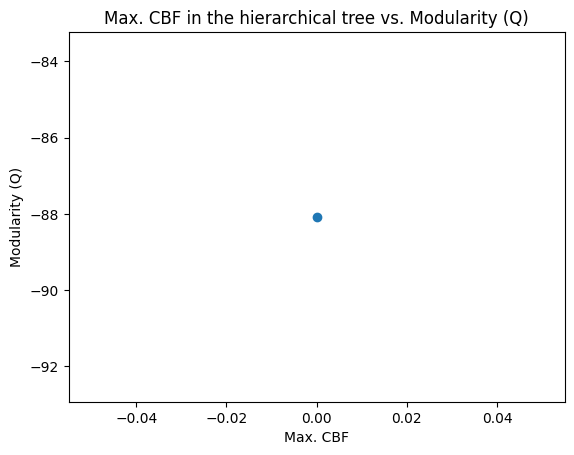

In [23]:
import matplotlib.pyplot as plt


plt.scatter(cbf_max, [v[0] for v in mean_energies.values()])
# plt.errorbar(cbf_max, [v[0] for v in mean_energies.values()], yerr=[v[0] for v in stds.values()])
# plt.yscale("log")
plt.ylabel("Modularity (Q)")
plt.xlabel("Max. CBF")
plt.title("Max. CBF in the hierarchical tree vs. Modularity (Q)");

In [211]:
from searchers.utils import HierarchicalRunMetadata

In [68]:
from utils import recover_ordering, plot_tree, get_extended_nodes

In [27]:
sampleset_metadatas[0].dwave_sampleset[0]

SampleSet(rec.array([([0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], -46.5       , 1, 0.  ),
           ([0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0], -46.41919192, 1, 0.  ),
           ([0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], 

In [25]:
import dwave.inspector


dwave.inspector.show(sampleset_metadatas[0].dwave_sampleset[0])

ValueError: invalid combination of arguments provided: if data capture not enabled, problem/response/solver have to be specified; also, make sure a structured problem is being inspected

In [71]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata


quadratics_mean = []
quadratics_std = []
linears_mean = []
linears_std = []
energies = []
for pr_id in pr_ids:
    pd = get_problem(pr_id)
    quads = np.array(list(pd.problem["quadratic"].values()))
    quadratics_mean.append(np.mean(quads))
    quadratics_std.append(np.std(quads))
    linears = np.array(list(pd.problem["linear"].values()))
    linears_mean.append(np.mean(linears))
    linears_std.append(np.std(linears))
    energies.append(pd.response.energies[0])

NameError: name 'pr_ids' is not defined

In [9]:
fe = ["sampleset_adv.pkl", "sampleset_adv_serializable.pkl", "sampleset_adv.npy"]

In [ ]:
import os
import re


hashes = list(nodes.keys())

result_files = []
result_files_handles = []
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            if result_handle:
                # result_handle = re.split(rf"(_{fe[0]})$", result_handle.group(0))
                result_handle = re.split("sampleset", result_handle.group(0))
                if comm_hash in hashes:
                    result_files.append(os.path.join(root, file))
                    result_files_handles.append(result_handle[0])

In [18]:
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            print(result_handle)
            result_handle = re.split("sampleset", result_handle.group(0))
            print(result_handle)

AttributeError: 'NoneType' object has no attribute 'group'

In [26]:
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields

In [36]:
path = "saving"
field_names = list(HierarchicalRunMetadata.__dataclass_fields__.keys())

In [39]:
import pickle
import os
from searchers.utils import HierarchicalRunMetadata


path = "./saving"

field_names = [f.name for f in fields(HierarchicalRunMetadata)]


loaded_data = {}

print("Loading files...")

for field_name in field_names:
    filename = f"exp_{field_name}.pkl" 
    file_path = os.path.join(path, filename)
    
    if os.path.exists(file_path):
        try:
            with open(file_path, 'rb') as f:
                loaded_data[field_name] = pickle.load(f) 
            print(f"✅ Successfully loaded: {filename}")
        except Exception as e:
            print(f"❌ Error loading {filename}: {e}")
    else:
        print(f"⚠️ File not found (skipping): {filename}")

# --- Result ---
print("\n--- Summary ---")
print(f"Total fields loaded: {len(loaded_data)}")

Loading files...
✅ Successfully loaded: exp_dwave_sampleset_metadata.pkl
✅ Successfully loaded: exp_time_measurements.pkl
❌ Error loading exp_dwave_sampleset.pkl: EmbeddedStructure is immutable
✅ Successfully loaded: exp_timing.pkl
✅ Successfully loaded: exp_problem_id.pkl
✅ Successfully loaded: exp_community_hash.pkl
✅ Successfully loaded: exp_chain_strength.pkl
✅ Successfully loaded: exp_chain_break_fraction.pkl
✅ Successfully loaded: exp_chain_break_method.pkl
❌ Error loading exp_embedding.pkl: EmbeddedStructure is immutable
✅ Successfully loaded: exp_warnings.pkl
⚠️ File not found (skipping): exp_community.pkl

--- Summary ---
Total fields loaded: 9


In [52]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata
from dwave.inspector.adapters import enable_data_capture


enable_data_capture()

{}